This notebook examines a baseline model for forecasting store sales data. During the initial EDA of average daily sales across stores, it was observed that there is a strong weekly seasonal pattern in the data, so the baseline model will be a seasonal model that uses the previous week's values as the forecasts.

## Evaluate model

In [1]:
from ssdf.training import eval, train

/home/tiloye/projects/store-sales-demand-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
forecaster = train.get_model()
df = train.get_data()

Splitting data into train and test sets...
Logging the training data to MLflow...
Evaluating forecaster on 5 validation set(s)...
Average RMSLE across all folds: 0.5314000239072426
Standard deviation of RMSLE across all folds: 0.017311304010044045
Plotting average daily sales for random stores from cross validation result


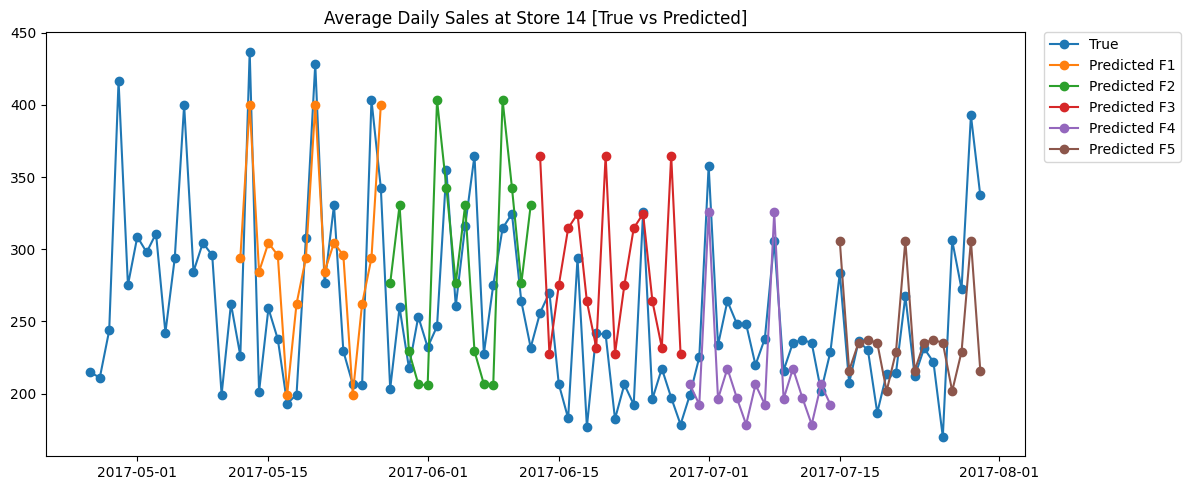

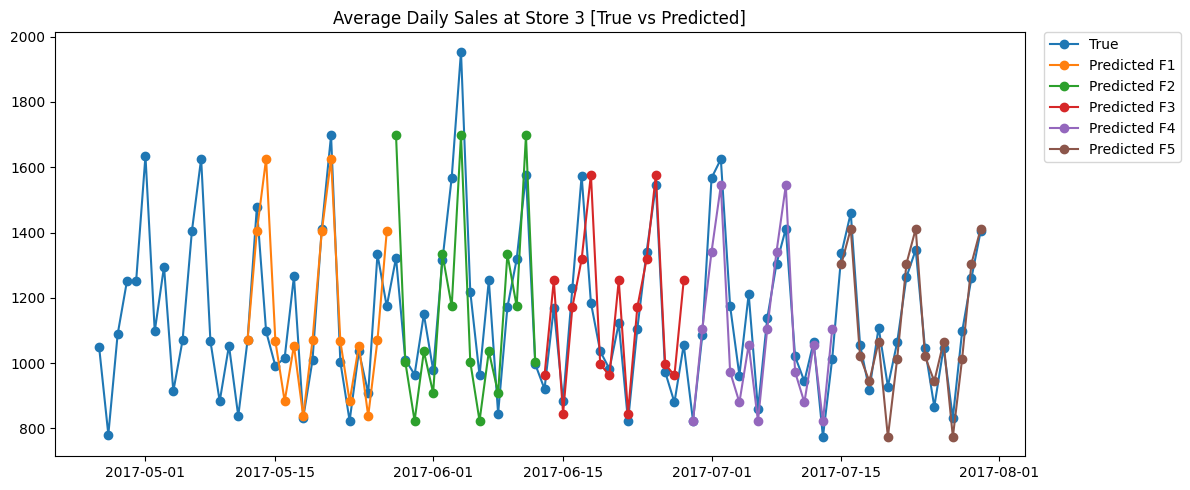

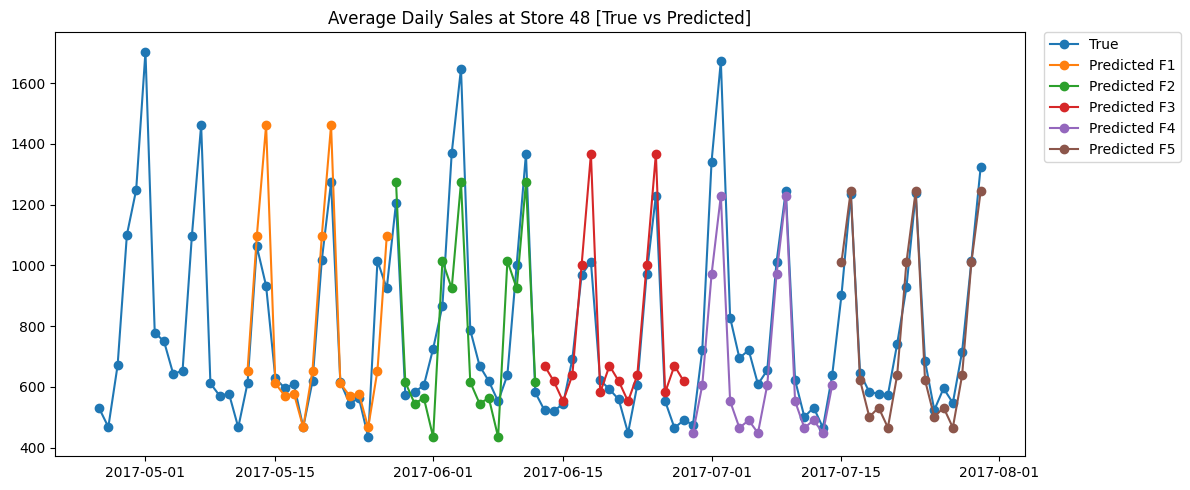

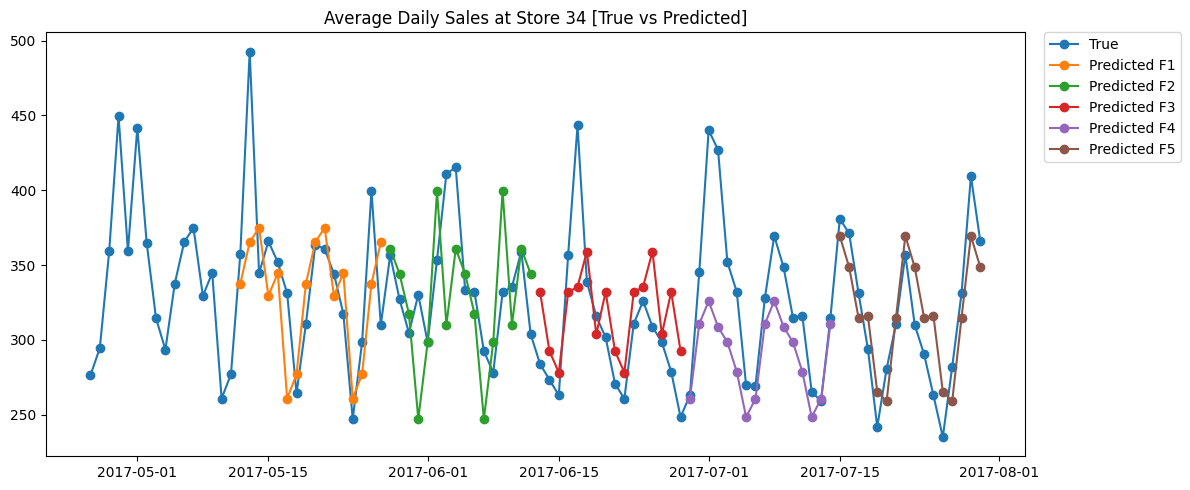

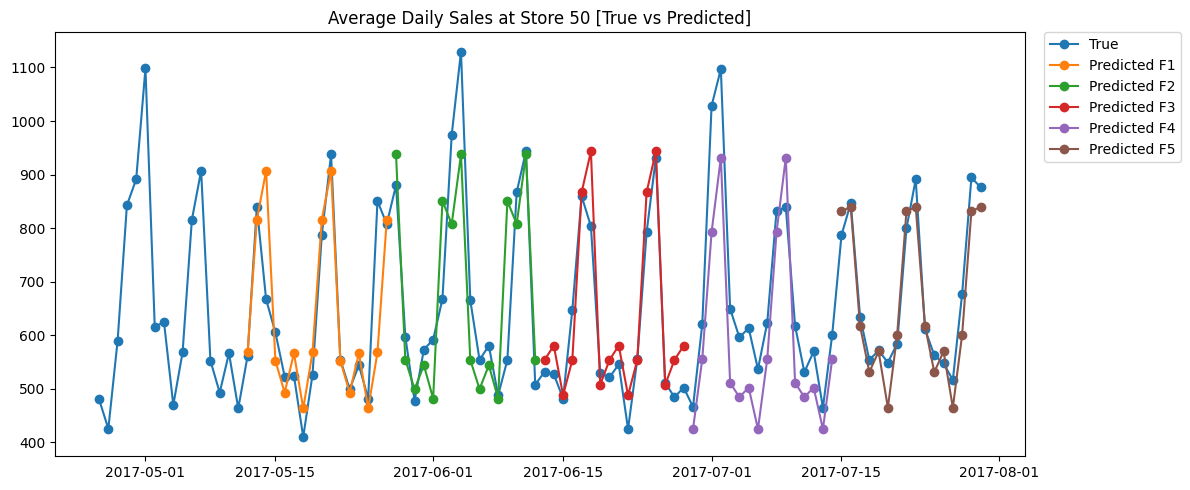

Evaluating forecaster on test set...
Test RMSLE: 0.6170404161294091
Plotting average daily sales for random stores from test set...


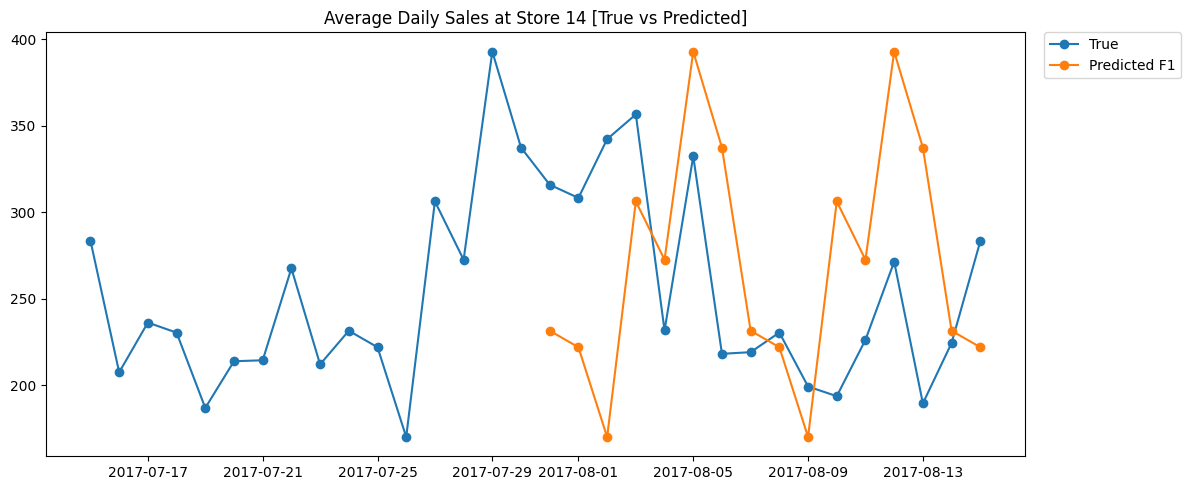

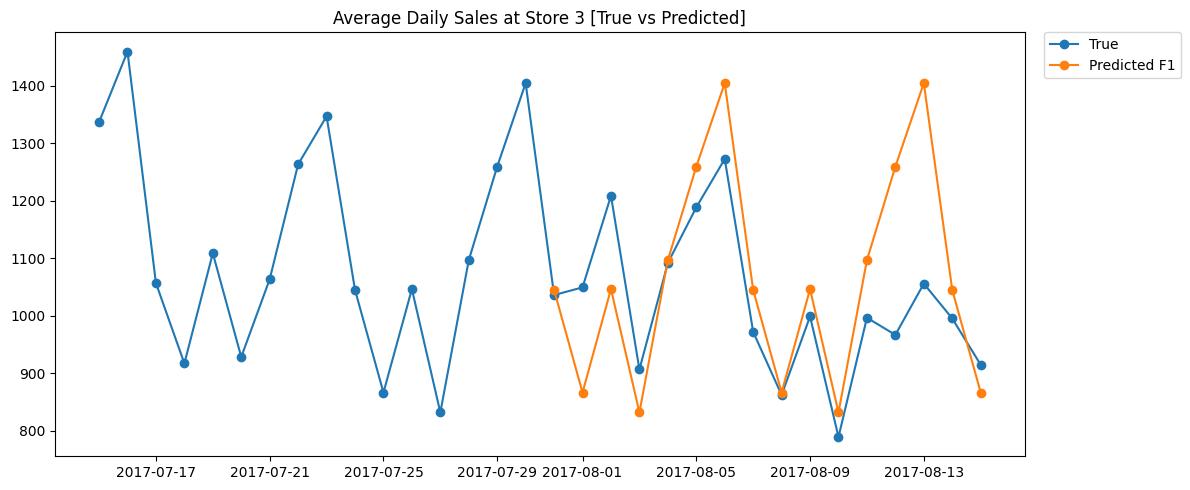

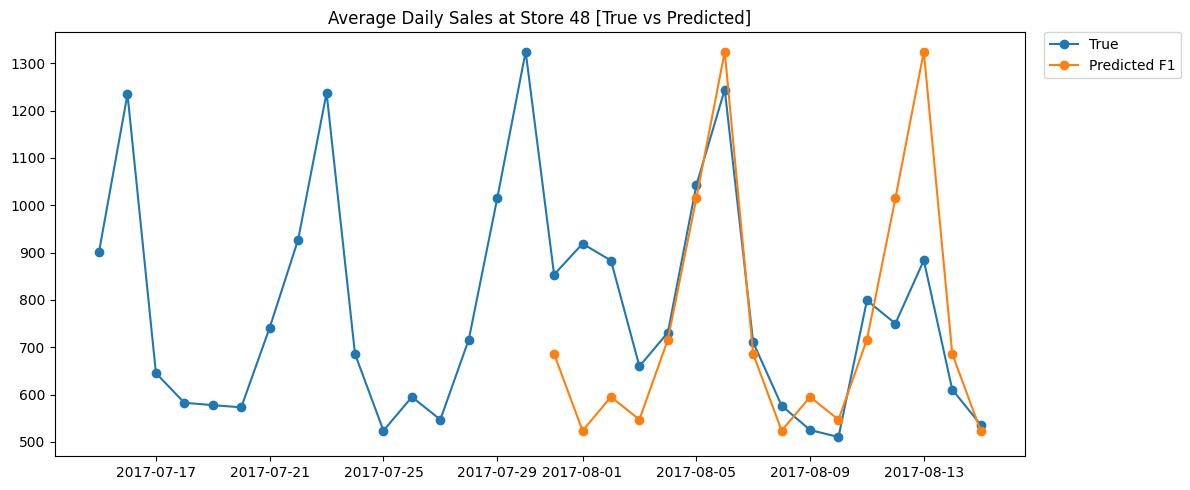

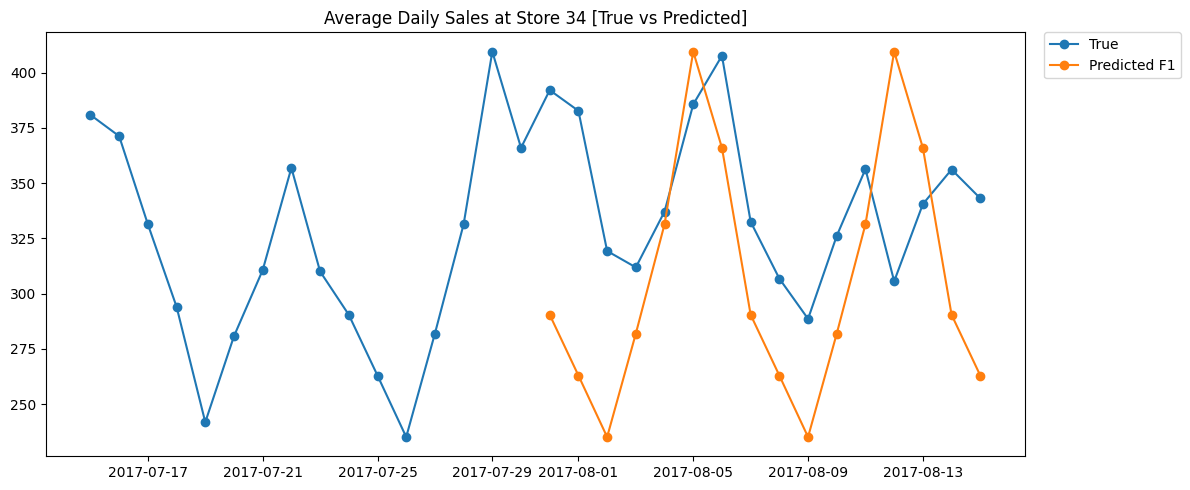

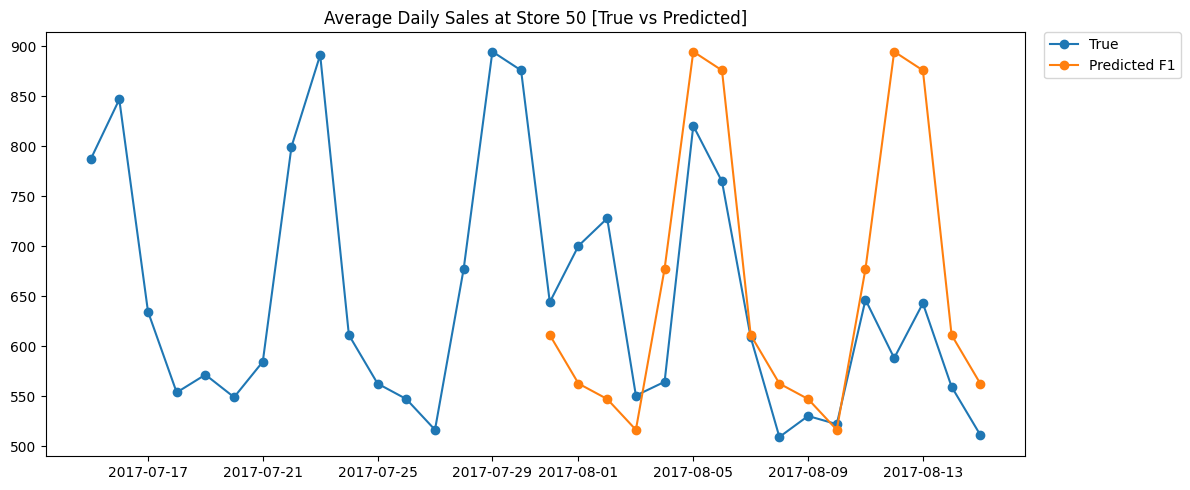

🏃 View run exultant-horse-798 at: http://localhost:5000/#/experiments/1/runs/2eabcebdb207441a81f0f1c2a92fd03a
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [3]:
result, mlflow_run =  eval.run(forecaster, df, k=5)

## Train model on full Data

In [4]:
run_id = mlflow_run.info.run_id

In [5]:
fitted_forecaster, train_run = train.run(df, exp_run_id=run_id)

Logging training data to MLflow
Training the forecaster


2026/04/26 00:46:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training complete
Logging the trained model to MLflow


2026/04/26 00:46:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run exultant-horse-798 at: http://localhost:5000/#/experiments/1/runs/2eabcebdb207441a81f0f1c2a92fd03a
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Generate predictions

In [6]:
import mlflow
from ssdf.inference import predict

In [7]:
model_id = mlflow.get_run(train_run.info.run_id).outputs.model_outputs[0].model_id
model_uri = f"models:/{model_id}"
model = predict.run(model_uri)

Loading model and generating forecasts...


Successfully generated forecasts
Saving forecasts...
Successfully saved forecasts
